In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

In [5]:
# ---------------------------------------------------------
# Standard C-infinity bump supported in 1 < t < 2
# ---------------------------------------------------------

def bump_scalar(t):
    if 1.0 < t < 2.0:
        return np.exp(-1.0 / ((t - 1.0) * (2.0 - t)))
    return 0.0


def bump_prime_scalar(t):
    if 1.0 < t < 2.0:
        b = bump_scalar(t)
        denominator = (t - 1.0) ** 2 * (2.0 - t) ** 2
        return b * (3.0 - 2.0 * t) / denominator
    return 0.0


def bump(t):
    """Vectorized version of b(t)."""
    t = np.asarray(t, dtype=float)
    out = np.zeros_like(t)

    mask = (t > 1.0) & (t < 2.0)
    x = t[mask]

    out[mask] = np.exp(
        -1.0 / ((x - 1.0) * (2.0 - x))
    )

    return out

In [6]:

# ---------------------------------------------------------
# Normalization epsilon
#
# epsilon^2 ∫_1^2 (b'(t)^2 + b(t)^2) dt = 1/2
# ---------------------------------------------------------

A, _ = quad(
    lambda t: bump_prime_scalar(t) ** 2 + bump_scalar(t) ** 2,
    1.0,
    2.0,
    limit=300,
)

epsilon = 1.0 / np.sqrt(2.0 * A)

print(f"A       = {A:.12e}")
print(f"epsilon = {epsilon:.12f}")

A       = 2.286432576878e-03
epsilon = 14.787876077610


In [7]:
# ---------------------------------------------------------
# Counterexample amplitude
#
# rho_n(V) = epsilon sqrt(n) b(-log(V)/n)
#
# Support:
#     e^(-2n) < V < e^(-n)
# ---------------------------------------------------------

def rho_n(V, n):
    V = np.asarray(V, dtype=float)
    rho = np.zeros_like(V)

    positive = V > 0.0
    t = -np.log(V[positive]) / n

    rho[positive] = epsilon * np.sqrt(n) * bump(t)

    return rho


# Values of n to display
n_values = [2, 4, 6]


# ---------------------------------------------------------
# Print support and peak information
# ---------------------------------------------------------

for n in n_values:
    V_left = np.exp(-2.0 * n)
    V_right = np.exp(-n)

    V_support = np.geomspace(V_left, V_right, 5000)
    rho_support = rho_n(V_support, n)

    peak_index = np.argmax(rho_support)

    print(
        f"n={n}: "
        f"support=({V_left:.6e}, {V_right:.6e}), "
        f"V_peak={V_support[peak_index]:.6e}, "
        f"rho_max={rho_support[peak_index]:.6f}"
    )

n=2: support=(1.831564e-02, 1.353353e-01), V_peak=4.977711e-02, rho_max=0.383039
n=4: support=(3.354626e-04, 1.831564e-02), V_peak=2.477761e-03, rho_max=0.541699
n=6: support=(6.144212e-06, 2.478752e-03), V_peak=1.233358e-04, rho_max=0.663443


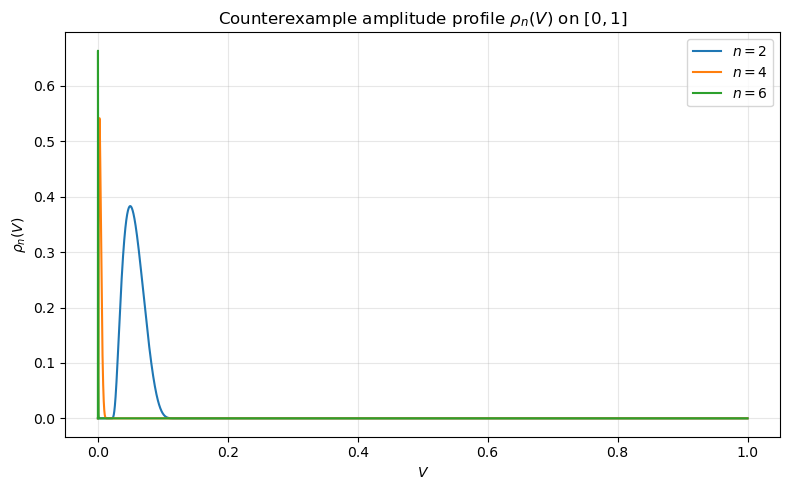

In [8]:
# ---------------------------------------------------------
# Plot 1: full interval 0 <= V <= 1
# ---------------------------------------------------------

V_full = np.unique(
    np.concatenate([
        [0.0],
        np.geomspace(1.0e-8, 0.2, 5000),
        np.linspace(0.2, 1.0, 1000),
    ])
)

plt.figure(figsize=(8, 5))

for n in n_values:
    plt.plot(V_full, rho_n(V_full, n), label=fr"$n={n}$")

plt.xlabel(r"$V$")
plt.ylabel(r"$\rho_n(V)$")
plt.title(r"Counterexample amplitude profile $\rho_n(V)$ on $[0,1]$")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

# Optional:
# plt.savefig("counterexample_rho_full_interval.png", dpi=200)

plt.show()

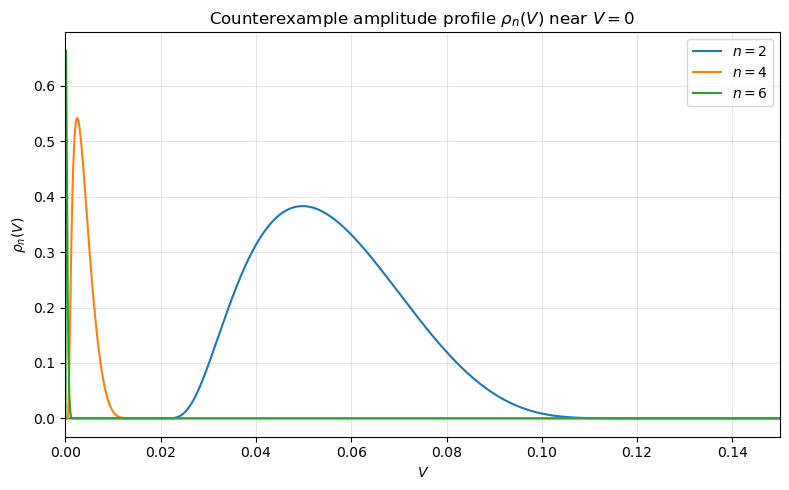

In [9]:
# ---------------------------------------------------------
# Plot 2: zoom to 0 <= V <= 0.15
# ---------------------------------------------------------

V_zoom = np.unique(
    np.concatenate([
        [0.0],
        np.geomspace(1.0e-8, 0.15, 7000),
        np.linspace(0.01, 0.15, 2000),
    ])
)

plt.figure(figsize=(8, 5))

for n in n_values:
    plt.plot(V_zoom, rho_n(V_zoom, n), label=fr"$n={n}$")

plt.xlim(0.0, 0.15)
plt.xlabel(r"$V$")
plt.ylabel(r"$\rho_n(V)$")
plt.title(r"Counterexample amplitude profile $\rho_n(V)$ near $V=0$")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

# Optional:
# plt.savefig("counterexample_rho_zoom_0p15.png", dpi=200)

plt.show()

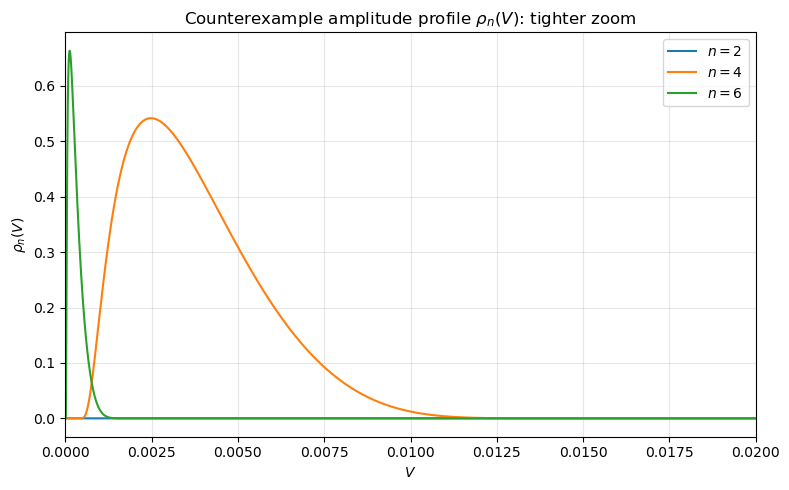

In [10]:
# ---------------------------------------------------------
# Plot 3: tighter zoom to 0 <= V <= 0.02
# ---------------------------------------------------------

V_tight = np.unique(
    np.concatenate([
        [0.0],
        np.geomspace(1.0e-8, 0.02, 7000),
        np.linspace(0.0, 0.02, 3000),
    ])
)

plt.figure(figsize=(8, 5))

for n in n_values:
    plt.plot(V_tight, rho_n(V_tight, n), label=fr"$n={n}$")

plt.xlim(0.0, 0.02)
plt.xlabel(r"$V$")
plt.ylabel(r"$\rho_n(V)$")
plt.title(r"Counterexample amplitude profile $\rho_n(V)$: tighter zoom")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

# Optional:
# plt.savefig("counterexample_rho_zoom_0p02.png", dpi=200)

plt.show()